<a href="https://colab.research.google.com/github/emirozyesil/DSA-210-term-project/blob/main/notebooks/04_machine_learning_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/nba_games_enriched.csv")
df.head()



,gameId,gameDateTimeEst,teamName,opponentTeamName,home,win,teamScore,opponentScore,q1Points,q2Points,...,Q3_diff,foulsPersonal,opponentFoulsPersonal,Foul_diff,fieldGoalsAttempted,threePointersAttempted,twoPointersAttempted,threePA_ratio,final_margin,close_game
0,22500300,2025-11-29 17:00:00,MAVERICKS,CLIPPERS,0,1,114,110,25.0,24.0,...,7.0,19.0,21.0,-2.0,90.0,39.0,51.0,0.433333,4,1
1,22500300,2025-11-29 17:00:00,CLIPPERS,MAVERICKS,1,0,110,114,28.0,28.0,...,-7.0,21.0,19.0,2.0,80.0,25.0,55.0,0.312500,-4,1
2,22500299,2025-11-29 16:00:00,NUGGETS,SUNS,0,1,130,112,30.0,33.0,...,8.0,20.0,23.0,-3.0,76.0,38.0,38.0,0.500000,18,0
3,22500299,2025-11-29 16:00:00,SUNS,NUGGETS,1,0,112,130,25.0,35.0,...,-8.0,23.0,20.0,3.0,88.0,42.0,46.0,0.477273,-18,0
4,22500298,2025-11-29 15:30:00,PELICANS,WARRIORS,0,0,96,104,18.0,20.0,...,3.0,21.0,23.0,-2.0,86.0,30.0,56.0,0.348837,-8,0


In [5]:
# Features for ML (keep it simple and relevant)
feature_cols = [
    "Q3_diff",
    "Foul_diff",
    "threePA_ratio",
    "home",
    "close_game"
]

target_col = "win"

ml_df = df[feature_cols + [target_col]].dropna()

X = ml_df[feature_cols]
y = ml_df[target_col]

print("Rows used:", len(ml_df))
print("Class balance (win rate):", y.mean())
X.head()


Rows used: 3472
Class balance (win rate): 0.5


,Q3_diff,Foul_diff,threePA_ratio,home,close_game
0,7.0,-2.0,0.433333,0,1
1,-7.0,2.0,0.312500,1,1
2,8.0,-3.0,0.500000,0,0
3,-8.0,3.0,0.477273,1,0
4,3.0,-2.0,0.348837,0,0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(X_train), len(X_test)


(2777, 695)

In [7]:
logreg_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", acc)


Logistic Regression Accuracy: 0.6848920863309352


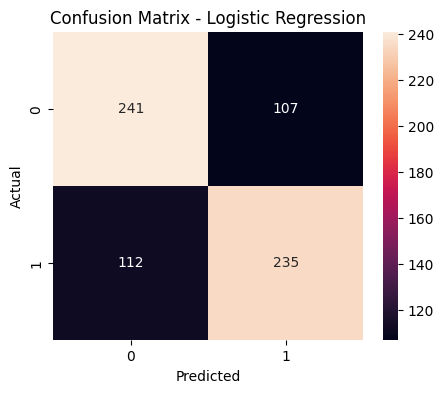

              precision    recall  f1-score   support

           0     0.6827    0.6925    0.6876       348
           1     0.6871    0.6772    0.6821       347

    accuracy                         0.6849       695
   macro avg     0.6849    0.6849    0.6849       695
weighted avg     0.6849    0.6849    0.6849       695



In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred, digits=4))


In [11]:
clf = logreg_model.named_steps["clf"]
coefs = clf.coef_[0]

importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefs
}).sort_values("coefficient", ascending=False)

importance



,feature,coefficient
0,Q3_diff,1.008977
3,home,0.169822
2,threePA_ratio,0.014030
4,close_game,-0.030917
1,Foul_diff,-0.256232


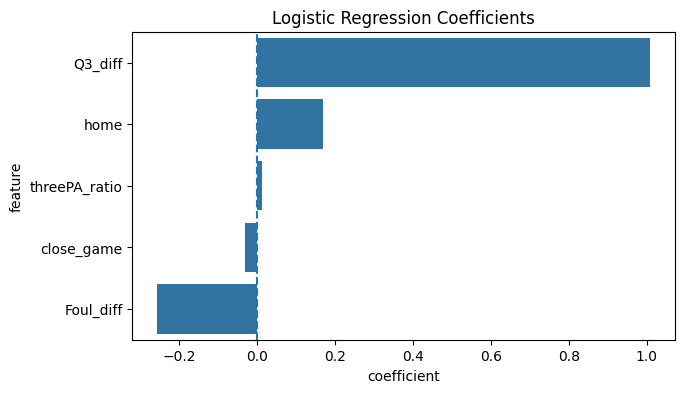

In [12]:
plt.figure(figsize=(7,4))
sns.barplot(data=importance, x="coefficient", y="feature")
plt.title("Logistic Regression Coefficients")
plt.axvline(0, linestyle="--")
plt.show()


## Conclusion

In this project, NBA game data was enriched with additional features such as
quarter-based score differences and shot selection ratios.
Exploratory analysis showed clear relationships between third-quarter performance
and winning probability.

Machine learning models confirmed these findings, with Q3 performance emerging as
the strongest predictor of game outcomes. Overall, the results suggest that
mid-game momentum plays a crucial role in determining NBA game results.
